# Stochastic model using skellam distribution for $\Delta N_g$
assuming a 1000-block pasture

In [ ]:
from matplotlib import pyplot as plt
import scipy as sp
import numpy as np

from math import exp
from math import factorial as fac

In [ ]:
R = 0.00888
K = 0.00772
Dt = 0.05

In [ ]:
def skellamPMF(N, Ng):
    """returns a vector containing the pmf for delta N_g given the initial value of N_g
    and the sheep population

    vector contains 11 elements, the pmf for delta N_g from -5 to +5
    """

    #if N_g = 1000, the skellam distribution reduces to a poisson with mean NRNg/A Dt
    #if N_g = 0, delta Ng = 0 with 100% certainty
    #sp.stats.skellam.pmf() does not work with either of the means equal to 0
    if Ng == 1000:
        ret = sp.stats.poisson.pmf(-np.arange(-5, 6), N*R*Ng/1000*Dt)
    elif Ng == 0:
        ret = np.zeros(11)
        ret[5]=1
    else:
        ret =  sp.stats.skellam.pmf(np.arange(-5, 6), K*Ng*(1-Ng/1000)*Dt, N*R*Ng/1000*Dt)

    #normalize - we are cutting off the distribution at +-5 so we need sum to be 1
    return ret/np.sum(ret)

In [ ]:
f, ax = plt.subplots()

ax.plot(np.arange(-5, 6), skellamPMF(435, 600), ".")
ax.plot(np.arange(-5, 6), skellamPMF(435, 800), ".")
ax.plot(np.arange(-5, 6), skellamPMF(435, 1000), ".")

ax.grid(True)

plt.show()

## Stochastic model using iterative skellam convolution

In [38]:
def step(N, Ng):
    """takes in the distribution of Ng at time t_0
    and returns the distribution of Ng at time t_0 + Delta t
    """

    Ng_t0Dt = np.zeros(1001)
    #for Ng=i at t=t0...
    for i in range(0, Ng.size):
        #skellam_entire[n] is the probability of ending at Ng=n given initial state Ng=i
        skellam_entire = np.zeros(1001)
        skellam = skellamPMF(N, i)
        #need to insert values from skellam distribution at appropriate locations
        for j in range(0, 11):
            if not(i+j-5 > 1000 or i+j-5 < 0):
                skellam_entire[i+j-5]=skellam[j]
        #add on to results, multiplying by probability of initial state Ng=i
        Ng_t0Dt += skellam_entire*Ng[i]

    #renormalize to correct for minor clipping near edges
    return Ng_t0Dt / np.sum(Ng_t0Dt)

In [39]:
def pmfE(p):
    """calculate the expected value of the pmf p
    p should be a vector of size 1001 where p[i] represents the probability of state x=i"""

    return np.sum(p * np.arange(0, 1001))

def pmfVariance(p):
    """calculate the variance of the pmf p
    p should be a vector of size 1001 where p[i] represents the probability of state x=i"""
    return np.sum(p*(np.arange(0, 1001)-pmfE(p))**2)

In [40]:
Ng0 = np.zeros(1001)
Ng0[500] = 1

b = Ng0

ng_result=np.array(Ng0, ndmin=2)

for i in range(0, 900):
    b = step(435, b)
    ng_result = np.append(ng_result, np.array(b, ndmin=2), 0)
    if i%10 == 0:
        print("finished iteration {0}".format(i))

finished iteration 0
finished iteration 10
finished iteration 20
finished iteration 30
finished iteration 40
finished iteration 50
finished iteration 60
finished iteration 70
finished iteration 80
finished iteration 90
finished iteration 100
finished iteration 110
finished iteration 120
finished iteration 130
finished iteration 140
finished iteration 150
finished iteration 160
finished iteration 170
finished iteration 180
finished iteration 190
finished iteration 200
finished iteration 210
finished iteration 220
finished iteration 230
finished iteration 240
finished iteration 250
finished iteration 260
finished iteration 270
finished iteration 280
finished iteration 290
finished iteration 300
finished iteration 310
finished iteration 320
finished iteration 330
finished iteration 340
finished iteration 350
finished iteration 360
finished iteration 370
finished iteration 380
finished iteration 390
finished iteration 400
finished iteration 410
finished iteration 420
finished iteration 430

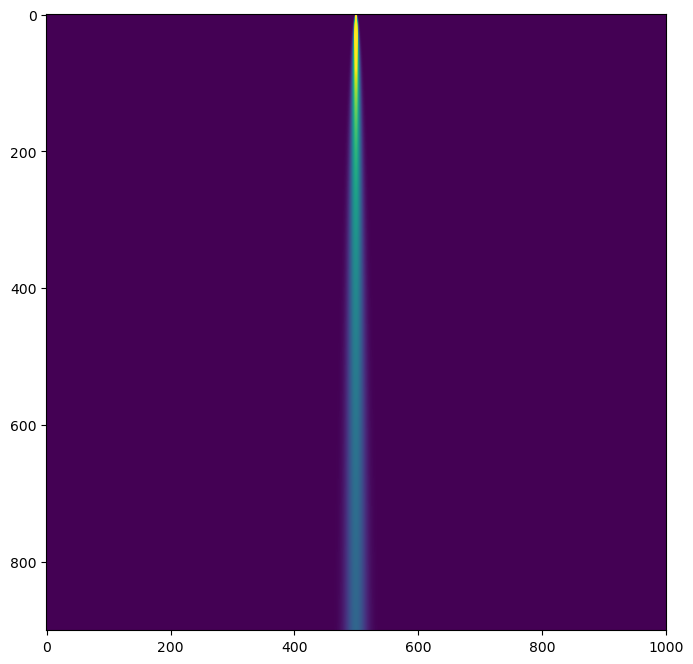

In [41]:
f, ax = plt.subplots(figsize=(8,8))
ax.imshow(ng_result, vmin=0, vmax=0.1, aspect="auto")
plt.show()

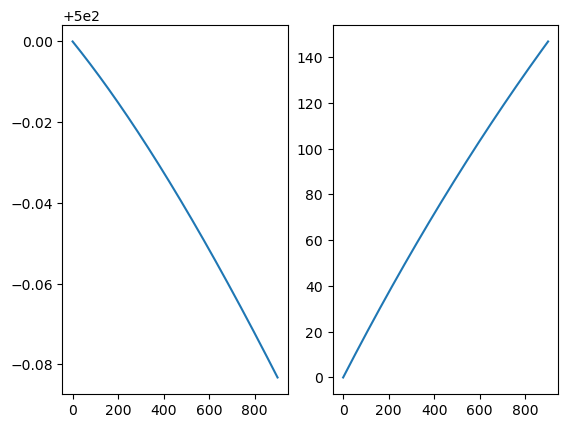

In [43]:
f, (ax1, ax2) = plt.subplots(ncols=2)

ax1.plot(np.array([pmfE(ng_result[x]) for x in range(0, ng_result.shape[0])]))
ax2.plot([pmfVariance(ng_result[x]) for x in range(0, ng_result.shape[0])])

plt.show()

In [46]:
np.sum(ng_result[899])

1.0